# Benchmarking

In [65]:
from sgkan import gaussian_process_models as gp
from sgkan import surrogate_guided_kan as sgkan
importlib.reload(sgkan)

<module 'sgkan.surrogate_guided_kan' from '/Users/gizemnurdal/Workspace/swim-meets-kans/sgkan/surrogate_guided_kan.py'>

In [1]:
import numpy as np
import importlib
import datasets
import sys
import torch
import time
import gpytorch
sys.path.insert(0, '/Users/gizemnurdal/Workspace/swim-meets-kans/pykan')
sys.path.insert(0, '/Users/gizemnurdal/Workspace/swim-meets-kans/sgkan')

from sklearn.linear_model import Ridge
from datasets import (
    load_dataset,
    min_max_scale_dataset
)

from hkan.hkan import (
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    make_hkan_layer, extend_hkan, set_tqdm_disable,
)

from kan import KAN # type: ignore
from sgkan import surrogate_guided_kan as sgkan
from sgkan import gaussian_process_models as gp
from sgkan import gp_swim_like_pairs as gs
import evaluation_metrics as em
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
import optuna
from optuna.pruners import MedianPruner

torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")



Device: cpu


/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Utilities Functions

In [2]:
def build_hkan_from_params(model_params, tqdm_disable=False):
    """
    Build an HKAN model from a list of layer-param dicts.

    Args:
        model_params: List of dicts with layer config (layer, n_vars_out, basis_fn, etc.)
        tqdm_disable: Disable progress bars in training

    Returns:
        Constructed HKAN model
    """
    # Ensure layers are processed in order (layer 0 first, then extended sequentially)
    params = sorted(model_params, key=lambda p: int(p["layer"]))
    model = None
    set_tqdm_disable(tqdm_disable)

    for p in params:
        layer_idx = int(p["layer"])
        n_vars_out = p["n_vars_out"]
        basis_fn = p["basis_fn"]
        n_basis = p.get("n_basis", 10)
        centers = p.get("centers", "random")
        reg = p.get("regressor", Ridge())

        if layer_idx == 0:
            # Create first layer with specified parameters
            model = make_hkan_layer(
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=reg,
            )
        else:
            # Stack additional layers on top of existing model
            if model is None:
                raise ValueError("First layer (layer 0) must be provided before extending.")
            model = extend_hkan(
                model,
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=reg,
            )
    return model

def fit_hkan(model, X_train, y_train):
    """Train HKAN model on training data and report elapsed time."""
    if model:
        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time
        print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")

def predict_hkan(model, X_test):
    """Make predictions with HKAN model and report elapsed time."""
    if model:
        start_time = time.time()
        predictions = model.predict(X_test)
        elapsed_time = time.time() - start_time
        print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
        return predictions

In [3]:
def build_kan(width, grid=3, k=3, seed=42):
    """
    Build a KAN model with specified architecture.

    Args:
        width: List of layer widths, e.g., [2, 5, 1]
        grid: Grid size for spline basis
        k: Spline degree
        seed: Random seed for reproducibility

    Returns:
        KAN model instance
    """
    return KAN(width=width, grid=grid, k=k, seed=seed, device=device)

def fit_kan(model, X_train, y_train, X_test, y_test, steps=50, opt="Adam", lamb=0.01):
    """
    Train a KAN model with test data for validation.

    Args:
        model: KAN model instance
        X_train, y_train: Training data
        X_test, y_test: Test data for validation
        steps: Number of training iterations
        opt: Optimizer ("LBFGS" or "Adam")
        lamb: Regularization coefficient

    Returns:
        Trained KAN model
    """
    start_time = time.time()
    # Convert numpy arrays to torch tensors on the specified device
    X_train_tensor = torch.tensor(X_train, dtype=torch.float64, device=device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float64, device=device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64, device=device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float64, device=device)
    
    # Package data into KAN-compatible format
    dataset = {
        'train_input': X_train_tensor, 
        'train_label': y_train_tensor,
        'test_input': X_test_tensor,
        'test_label': y_test_tensor
    }
    model.fit(dataset, opt=opt, steps=steps, lamb=lamb)
    
    elapsed_time = time.time() - start_time
    print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")
    return model

def predict_kan(model, X_test):
    """
    Make predictions with a KAN model.

    Args:
        model: Trained KAN model
        X_test: Input data for prediction

    Returns:
        Predictions as numpy array
    """
    start_time = time.time()
    # Convert to tensor, forward pass, then detach and convert back to numpy
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64, device=device)
    predictions = model(X_test_tensor).detach().cpu().numpy()
    elapsed_time = time.time() - start_time
    print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
    return predictions

In [ ]:
# ─── Kernel utilities ──────────────────────────────────────────
def create_rbf_kernel(input_dim):
    """
    Create RBF kernel with ARD (automatic relevance determination).
    
    RBF: Choose it when you are confident the function is globally smooth with no 
    sharp local changes.
    """
    return gpytorch.kernels.ScaleKernel(
        gpytorch.kernels.RBFKernel(ard_num_dims=input_dim)
    )

def create_matern_kernel(input_dim, nu=2.5):
    """
    Create Matérn kernel with ARD (automatic relevance determination).
    
    Matérn ν=2.5: Choose it as the default for most real-world and physical data, 
    where the function is smooth enough to be differentiable but not so smooth that 
    infinitely many derivatives are guaranteed.
    """
    return gpytorch.kernels.ScaleKernel(
        gpytorch.kernels.MaternKernel(nu=nu, ard_num_dims=input_dim)
    )

def create_rbf_matern_kernel(input_dim):
    """Create product of RBF and Matern kernels."""
    rbf = gpytorch.kernels.RBFKernel(ard_num_dims=input_dim)
    matern = gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=input_dim)
    return gpytorch.kernels.ScaleKernel(rbf * matern)

def fit_sgkan(X_train, y_train, layer_configs, activation=torch.tanh, kernel=None, 
              lr=0.1, num_inducing=500, num_iters=100):
    """
    Train SGKAN (Surrogate-Guided KAN) model with optional custom kernel and GP hyperparameters.
    
    SGKAN uses a Gaussian process surrogate to guide the training of a KAN-like model,
    combining the interpretability of KAN with the uncertainty quantification of GPs.

    Args:
        X_train: Training input data (numpy array)
        y_train: Training target data (numpy array)
        layer_configs: List of dicts with layer configuration (width, M, G, T parameters)
        activation: Activation function (default: torch.tanh)
        kernel: GPyTorch kernel for the Gaussian process (default: RBF with ARD)
        lr: Learning rate for GP training (default: 0.1)
        num_inducing: Number of inducing points for sparse GP (default: 500)
        num_iters: Number of training iterations for GP (default: 100)

    Returns:
        Tuple of (layers, W_out) representing the trained SGKAN model
    """
    start_time = time.time()
    # Convert numpy arrays to torch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float64)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float64)
    
    # Build the SGKAN model with the specified configuration and GP hyperparameters
    layers, W_out = sgkan.build_sgkan(
        X_train_tensor, y_train_tensor, layer_configs, 
        activation=activation, kernel=kernel,
        lr=lr, num_inducing=num_inducing, num_iters=num_iters
    )
    
    elapsed_time = time.time() - start_time
    print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")
    return layers, W_out

def predict_sgkan(layers, W_out, X_test, activation=torch.tanh):
    """
    Make predictions with a trained SGKAN model.

    Args:
        layers: List of SGKAN layers from fit_sgkan
        W_out: Output weights from fit_sgkan
        X_test: Input data for prediction (numpy array)
        activation: Activation function used during training (default: torch.tanh)

    Returns:
        Predictions as numpy array
    """
    start_time = time.time()
    # Convert to tensor and pass through the trained model
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64)
    predictions = sgkan.predict_sgkan(layers, W_out, X_test_tensor, activation=activation).detach().numpy()
    elapsed_time = time.time() - start_time
    print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
    return predictions

In [5]:
def print_results(results):
    """
    Pretty-print evaluation results in a formatted table.
    
    Args:
        results: Dict with structure {'train': {'mae': float, 'rmse': float},
                                     'test': {'mae': float, 'rmse': float}}
    """
    # Format header row
    print(f"{'Metric':<15} {'Train':<20} {'Test':<20}")
    print("-" * 55)
    
    # Print MAE and RMSE metrics with scientific notation for readability
    for metric in ['mae', 'rmse']:
        train_val = results['train'][metric]
        test_val = results['test'][metric]
        print(f"{metric.upper():<15} {train_val:<20.6e} {test_val:<20.6e}")

def plot_3d_surface(dataset_name, X_test, y_test, y_pred):
    """
    Plot 3D surface comparison of predicted vs actual values.
    
    Creates side-by-side 3D surface plots for visual comparison of model predictions
    against ground truth. Useful for analyzing model behavior over the input space.

    Args:
        dataset_name: Name of the dataset (used in plot titles)
        X_test: Input test data with shape (n_samples, 2) for 2D input space
        y_test: Ground truth output values
        y_pred: Model predictions matching y_test shape
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    n_samples = len(X_test)
    # Reshape 1D arrays into 2D grids for surface plotting
    grid_size = int(np.sqrt(n_samples))
    
    fig = plt.figure(figsize=(14, 6))
    
    # Extract X1 and X2 dimensions and reshape for surface plotting
    X1 = X_test[:, 0].reshape(grid_size, grid_size)
    X2 = X_test[:, 1].reshape(grid_size, grid_size)
    
    # Plot predicted surface (left subplot)
    ax = fig.add_subplot(121, projection="3d")
    ax.plot_surface(X1, X2, y_pred.reshape(grid_size, grid_size), cmap="viridis")
    ax.set_title(f"{dataset_name} - Predicted")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Y")
    
    # Plot actual surface (right subplot)
    ax = fig.add_subplot(122, projection="3d")
    ax.plot_surface(X1, X2, y_test.reshape(grid_size, grid_size), cmap="viridis")
    ax.set_title(f"{dataset_name} - Actual")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Y")
    
    plt.tight_layout()
    plt.show()

## TF1 RESULTS

### HKAN

In [6]:
# Load TF1 dataset
tf1 = load_dataset("TF1")
tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = tf1["train_input"], tf1["test_input"], tf1["train_label"], tf1["test_label"]

In [7]:
print("TF1 X_train shape:", tf1_x_train.shape)
print("TF1 X_test shape:", tf1_x_test.shape)
print("TF1 y_train range:", tf1_y_train.min(), tf1_y_train.max())
print("TF1 y_train mean:", tf1_y_train.mean())

TF1 X_train shape: (5000, 2)
TF1 X_test shape: (10000, 2)
TF1 y_train range: 0.00926302338925278 0.98881776725053
TF1 y_train mean: 0.5053805775495802


In [8]:
# TF1 model params
tf1_model_params = [
    {
        "layer": 0,
        "n_vars_out": 932,
        "basis_fn": Sigmoid(s=1),
        "n_basis": 2,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=33),
        "n_basis": 13,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=10),
    }
]
tf1_model = build_hkan_from_params(tf1_model_params)
tf1_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,932
,n_basis,2
,centers,'random_data_points'
,basis_fn,<hkan.hkan.Si...t 0x17ca8f690>
,base_regressor,Ridge(alpha=0.1)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [9]:
# Fit HKAN
fit_hkan(tf1_model,  tf1_x_train, tf1_y_train)
tf1_results = em.evaluate(
    tf1_model,
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.44it/s]



✓ Training completed in 3.7488 seconds


In [10]:
print_results(tf1_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.861605e-11         2.110567e-11        
RMSE            2.476009e-11         3.204369e-11        


In [11]:
tf1_y_test_pred = predict_hkan(tf1_model, tf1_x_test)

✓ Prediction completed in 3.1481 seconds


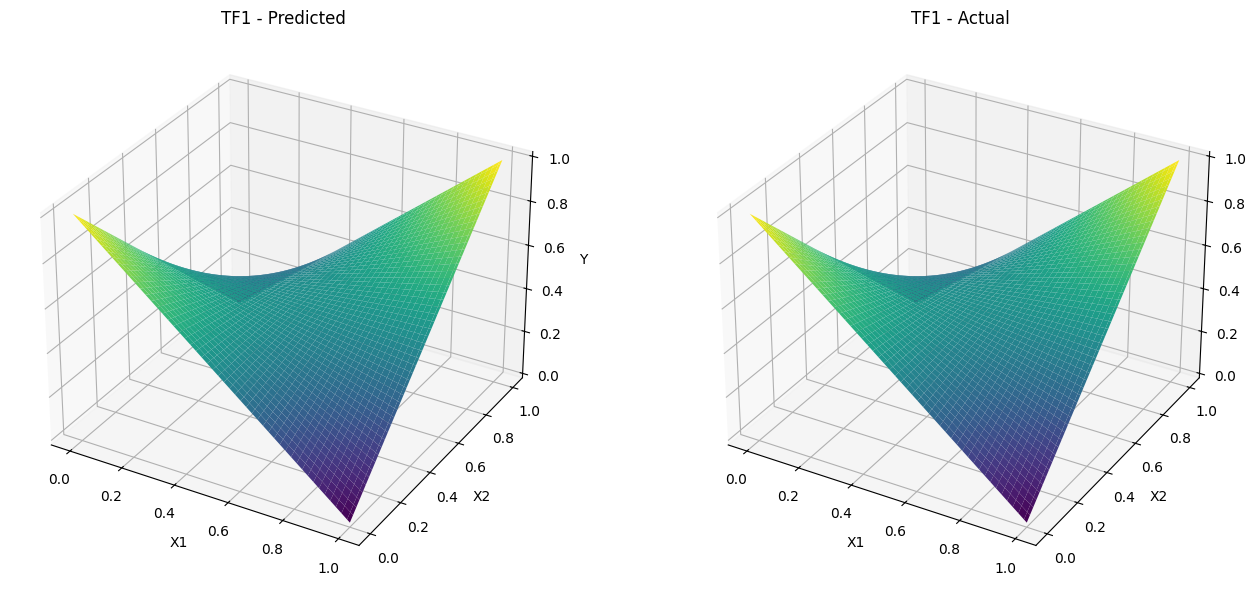

In [12]:
plot_3d_surface("TF1", tf1_x_test, tf1_y_test, tf1_y_test_pred)

### KAN

In [13]:
# Wrapper to add predict method for em.evaluate compatibility
class KANModel:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float64, device=device)
        return self.model(X_tensor).detach().cpu().numpy()

In [14]:
from sklearn.model_selection import KFold

def objective_kan(trial, X_train, y_train, X_test, y_test, n_splits=5):
    """
    Objective function for Optuna to find the best KAN architecture with K-Fold CV.
    
    Uses K-Fold Cross-Validation on training data to evaluate architectures robustly.
    Searches over predefined architecture set W from the HKAN paper.

    Only the network width configuration is searched. All other parameters 
    (grid, spline order k, optimizer, steps) are fixed at KAN defaults.

    The architecture set W is parameterised by n = X_train.shape[1]:
        W = {[n,1], [n,2,1], [n,n+1,1], [n,2n+1,1], [n,2,2,1],
             [n,n+1,2,1], [n,2n+1,2,1], [n,n+1,n+1,1],
             [n,2n+1,n+1,1], [n,2n+1,2n+1,1]}

    Args:
        trial: Optuna trial object
        X_train, y_train: Training data
        X_test, y_test: Test data for final evaluation
        n_splits: Number of folds for cross-validation (default: 5)

    Returns:
        float: Average validation RMSE across all folds (what Optuna minimizes)
    """
    n = X_train.shape[1]

    # Architecture search space W from the HKAN paper
    width_options = [
        [n, 1],
        [n, 2, 1],
        [n, n + 1, 1],
        [n, 2 * n + 1, 1],
        [n, 2, 2, 1],
        [n, n + 1, 2, 1],
        [n, 2 * n + 1, 2, 1],
        [n, n + 1, n + 1, 1],
        [n, 2 * n + 1, n + 1, 1],
        [n, 2 * n + 1, 2 * n + 1, 1],
    ]

    # Suggest architecture
    width_idx = trial.suggest_categorical("width_idx", list(range(len(width_options))))
    width = width_options[width_idx]

    # K-Fold Cross-Validation on training data
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_val_rmses = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split into fold train/validation
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        # Build and train model with suggested architecture
        model = build_kan(width=width, grid=3, k=3, seed=42)
        fit_kan(model, X_fold_train, y_fold_train, 
                X_fold_val, y_fold_val,
                steps=100, opt="Adam", lamb=1e-3)
        
        # Evaluate on this fold's validation set
        results = em.evaluate(
            KANModel(model),
            X_fold_train, y_fold_train,
            X_fold_val, y_fold_val
        )
        fold_val_rmses.append(results['test']['rmse'])
    
    # Average validation RMSE across all folds (what Optuna minimizes)
    avg_val_rmse = float(np.mean(fold_val_rmses))
    
    # Also evaluate on the actual test set for reference (only once, not per fold)
    final_model = build_kan(width=width, grid=3, k=3, seed=42)
    fit_kan(final_model, X_train, y_train, X_test, y_test, steps=100, opt="Adam", lamb=1e-3)
    test_results = em.evaluate(KANModel(final_model), X_train, y_train, X_test, y_test)
    test_rmse = float(test_results['test']['rmse'])
    
    # Store test RMSE as user attribute (will appear in trials dataframe)
    trial.set_user_attr("test_rmse", test_rmse)
    trial.set_user_attr("val_rmse", avg_val_rmse)
    
    # Return validation RMSE for optimization
    return avg_val_rmse


# --- Study setup with K-Fold CV -----------------------------------------------
print("=" * 70)
print("Optimizing KAN architecture with 5-Fold Cross-Validation on TF1")
print("=" * 70)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.GridSampler(
        {"width_idx": list(range(10))}  # Exhaustive over all 10 architectures
    ),
)

n = tf1_x_train.shape[1]
width_options = [
    [n, 1], [n, 2, 1], [n, n+1, 1], [n, 2*n+1, 1], [n, 2, 2, 1],
    [n, n+1, 2, 1], [n, 2*n+1, 2, 1], [n, n+1, n+1, 1],
    [n, 2*n+1, n+1, 1], [n, 2*n+1, 2*n+1, 1],
]

study.optimize(
    lambda trial: objective_kan(
        trial, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, n_splits=5
    ),
    n_trials=10,
    show_progress_bar=True,
)

# --- Results ---------------------------------------------------------------
print("\n" + "=" * 70)
print("Best trial results:")
print("=" * 70)
print(f"Best CV Validation RMSE: {study.best_value:.6f}")
best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
print(f"Best width_idx:          {study.best_params['width_idx']}")
print(f"Best architecture:       {width_options[study.best_params['width_idx']]}")

# Display all trials with both validation and test RMSE
trials_df = study.trials_dataframe()
print(f"\nAll {len(trials_df)} trials:")
print(trials_df[['number', 'value', 'params_width_idx', 'user_attrs_val_rmse', 'user_attrs_test_rmse']].to_string())

[I 2026-06-05 16:26:16,714] A new study created in memory with name: no-name-58f11fbd-bf28-42fa-8c3d-1dfce706df96


Optimizing KAN architecture with 5-Fold Cross-Validation on TF1


  0%|          | 0/10 [00:00<?, ?it/s]

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e-01 | test_loss: 1.73e-01 | reg: 2.38e+01 | : 100%|█| 100/100 [00:06<00:00, 14.34


saving model version 0.1

✓ Training completed in 6.9766 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.71e-01 | test_loss: 1.71e-01 | reg: 2.65e+01 | : 100%|█| 100/100 [00:06<00:00, 14.68


saving model version 0.1

✓ Training completed in 6.8168 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.75e-01 | test_loss: 1.77e-01 | reg: 3.23e+01 | : 100%|█| 100/100 [00:06<00:00, 14.59


saving model version 0.1

✓ Training completed in 6.8565 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.72e-01 | test_loss: 1.71e-01 | reg: 1.52e+01 | : 100%|█| 100/100 [00:06<00:00, 14.79


saving model version 0.1

✓ Training completed in 6.7668 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.70e-01 | test_loss: 1.70e-01 | reg: 1.96e+01 | : 100%|█| 100/100 [00:06<00:00, 15.53


saving model version 0.1

✓ Training completed in 6.4425 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.67e-01 | test_loss: 1.71e-01 | reg: 2.88e+01 | : 100%|█| 100/100 [00:22<00:00,  4.53
Best trial: 0. Best value: 0.16173:  10%|█         | 1/10 [00:56<08:24, 56.08s/it]

saving model version 0.1

✓ Training completed in 22.1139 seconds
[I 2026-06-05 16:27:12,793] Trial 0 finished with value: 0.16172950985702444 and parameters: {'width_idx': 2}. Best is trial 0 with value: 0.16172950985702444.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.33e-01 | test_loss: 5.27e-01 | reg: 4.49e+02 | : 100%|█| 100/100 [00:07<00:00, 13.44


saving model version 0.1

✓ Training completed in 7.4467 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e-01 | test_loss: 1.80e-01 | reg: 2.57e+02 | : 100%|█| 100/100 [00:07<00:00, 13.36


saving model version 0.1

✓ Training completed in 7.4878 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.32e-01 | test_loss: 5.33e-01 | reg: 5.81e+02 | : 100%|█| 100/100 [00:07<00:00, 13.39


saving model version 0.1

✓ Training completed in 7.4728 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.72e+00 | test_loss: 8.96e-01 | reg: 4.23e+02 | : 100%|█| 100/100 [00:07<00:00, 13.33


saving model version 0.1

✓ Training completed in 7.5101 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 9.09e-01 | test_loss: 7.02e-01 | reg: 6.38e+02 | : 100%|█| 100/100 [00:07<00:00, 12.51


saving model version 0.1

✓ Training completed in 8.0016 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.87e-01 | test_loss: 3.99e-01 | reg: 3.27e+02 | : 100%|█| 100/100 [00:25<00:00,  3.99
Best trial: 0. Best value: 0.16173:  20%|██        | 2/10 [01:59<08:01, 60.23s/it]

saving model version 0.1

✓ Training completed in 25.0529 seconds
[I 2026-06-05 16:28:15,927] Trial 1 finished with value: 0.5804935557402191 and parameters: {'width_idx': 8}. Best is trial 0 with value: 0.16172950985702444.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.89e-01 | test_loss: 1.87e-01 | reg: 7.90e+01 | : 100%|█| 100/100 [00:06<00:00, 14.52


saving model version 0.1

✓ Training completed in 6.8933 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.66e-01 | test_loss: 1.69e-01 | reg: 1.44e+01 | : 100%|█| 100/100 [00:07<00:00, 13.49


saving model version 0.1

✓ Training completed in 7.4156 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.66e-01 | test_loss: 1.68e-01 | reg: 1.20e+01 | : 100%|█| 100/100 [00:07<00:00, 13.82


saving model version 0.1

✓ Training completed in 7.2389 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.71e-01 | test_loss: 1.71e-01 | reg: 5.41e+01 | : 100%|█| 100/100 [00:07<00:00, 13.87


saving model version 0.1

✓ Training completed in 7.2140 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.67e-01 | test_loss: 1.66e-01 | reg: 1.98e+01 | : 100%|█| 100/100 [00:07<00:00, 13.62


saving model version 0.1

✓ Training completed in 7.3442 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.06e-01 | test_loss: 1.95e-01 | reg: 6.27e+01 | : 100%|█| 100/100 [00:26<00:00,  3.81
Best trial: 0. Best value: 0.16173:  30%|███       | 3/10 [03:01<07:08, 61.24s/it]

saving model version 0.1

✓ Training completed in 26.2287 seconds
[I 2026-06-05 16:29:18,376] Trial 2 finished with value: 0.16866488814328653 and parameters: {'width_idx': 4}. Best is trial 0 with value: 0.16172950985702444.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.34e+00 | test_loss: 3.15e+00 | reg: 4.49e+02 | : 100%|█| 100/100 [00:08<00:00, 11.79


saving model version 0.1

✓ Training completed in 8.4869 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.77e-01 | test_loss: 1.81e-01 | reg: 3.32e+02 | : 100%|█| 100/100 [00:08<00:00, 11.81


saving model version 0.1

✓ Training completed in 8.4686 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 8.76e+00 | test_loss: 7.57e+00 | reg: 4.65e+02 | : 100%|█| 100/100 [00:08<00:00, 11.62


saving model version 0.1

✓ Training completed in 8.6102 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.06e-01 | test_loss: 6.02e-01 | reg: 1.47e+02 | : 100%|█| 100/100 [00:08<00:00, 11.77


saving model version 0.1

✓ Training completed in 8.5035 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.77e-01 | test_loss: 1.74e-01 | reg: 1.93e+02 | : 100%|█| 100/100 [00:08<00:00, 12.12


saving model version 0.1

✓ Training completed in 8.2563 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 8.70e-01 | test_loss: 8.13e-01 | reg: 7.92e+02 | : 100%|█| 100/100 [00:26<00:00,  3.80
Best trial: 0. Best value: 0.16173:  40%|████      | 4/10 [04:10<06:25, 64.25s/it]

saving model version 0.1

✓ Training completed in 26.3345 seconds
[I 2026-06-05 16:30:27,247] Trial 3 finished with value: 2.3398971184487207 and parameters: {'width_idx': 9}. Best is trial 0 with value: 0.16172950985702444.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.68e-01 | test_loss: 1.63e-01 | reg: 1.48e+01 | : 100%|█| 100/100 [00:06<00:00, 14.46


saving model version 0.1

✓ Training completed in 6.9187 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e-01 | test_loss: 1.79e-01 | reg: 1.24e+01 | : 100%|█| 100/100 [00:06<00:00, 15.01


saving model version 0.1

✓ Training completed in 6.6648 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.66e-01 | test_loss: 1.69e-01 | reg: 5.91e+01 | : 100%|█| 100/100 [00:06<00:00, 15.99


saving model version 0.1

✓ Training completed in 6.2566 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.66e-01 | test_loss: 1.66e-01 | reg: 1.15e+01 | : 100%|█| 100/100 [00:06<00:00, 14.57


saving model version 0.1

✓ Training completed in 6.8676 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.69e-01 | test_loss: 1.69e-01 | reg: 1.57e+01 | : 100%|█| 100/100 [00:07<00:00, 14.00


saving model version 0.1

✓ Training completed in 7.1478 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.69e-01 | test_loss: 1.73e-01 | reg: 1.75e+01 | : 100%|█| 100/100 [00:22<00:00,  4.41
Best trial: 0. Best value: 0.16173:  50%|█████     | 5/10 [05:07<05:07, 61.50s/it]

saving model version 0.1

✓ Training completed in 22.6821 seconds
[I 2026-06-05 16:31:23,875] Trial 4 finished with value: 0.1748171372342609 and parameters: {'width_idx': 1}. Best is trial 0 with value: 0.16172950985702444.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.33e-01 | test_loss: 5.27e-01 | reg: 3.32e+02 | : 100%|█| 100/100 [00:07<00:00, 13.28


saving model version 0.1

✓ Training completed in 7.5335 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.66e-01 | test_loss: 1.70e-01 | reg: 3.64e+01 | : 100%|█| 100/100 [00:07<00:00, 13.35


saving model version 0.1

✓ Training completed in 7.4964 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.66e-01 | test_loss: 1.69e-01 | reg: 6.38e+01 | : 100%|█| 100/100 [00:07<00:00, 13.11


saving model version 0.1

✓ Training completed in 7.6346 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.72e-01 | test_loss: 1.99e-01 | reg: 5.29e+01 | : 100%|█| 100/100 [00:07<00:00, 12.53


saving model version 0.1

✓ Training completed in 7.9831 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.74e-01 | test_loss: 1.72e-01 | reg: 1.89e+02 | : 100%|█| 100/100 [00:07<00:00, 12.94


saving model version 0.1

✓ Training completed in 7.7331 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.72e-01 | test_loss: 1.77e-01 | reg: 1.84e+02 | : 100%|█| 100/100 [00:25<00:00,  3.92
Best trial: 0. Best value: 0.16173:  60%|██████    | 6/10 [06:11<04:09, 62.38s/it]

saving model version 0.1

✓ Training completed in 25.5455 seconds
[I 2026-06-05 16:32:27,960] Trial 5 finished with value: 0.24546858950505265 and parameters: {'width_idx': 6}. Best is trial 0 with value: 0.16172950985702444.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.73e-01 | test_loss: 1.65e-01 | reg: 4.42e+01 | : 100%|█| 100/100 [00:08<00:00, 12.21


saving model version 0.1

✓ Training completed in 8.1946 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.67e-01 | test_loss: 1.71e-01 | reg: 5.61e+01 | : 100%|█| 100/100 [00:08<00:00, 12.08


saving model version 0.1

✓ Training completed in 8.2825 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.18e-01 | test_loss: 2.00e-01 | reg: 7.96e+01 | : 100%|█| 100/100 [00:07<00:00, 12.75


saving model version 0.1

✓ Training completed in 7.8514 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.68e-01 | test_loss: 1.68e-01 | reg: 8.15e+01 | : 100%|█| 100/100 [00:07<00:00, 13.40


saving model version 0.1

✓ Training completed in 7.4658 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.67e-01 | test_loss: 1.66e-01 | reg: 3.86e+01 | : 100%|█| 100/100 [00:08<00:00, 12.32


saving model version 0.1

✓ Training completed in 8.1203 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.69e-01 | test_loss: 1.73e-01 | reg: 9.28e+01 | : 100%|█| 100/100 [00:23<00:00,  4.34
Best trial: 0. Best value: 0.16173:  70%|███████   | 7/10 [07:14<03:07, 62.61s/it]

saving model version 0.1

✓ Training completed in 23.0369 seconds
[I 2026-06-05 16:33:31,045] Trial 6 finished with value: 0.17158256336846925 and parameters: {'width_idx': 7}. Best is trial 0 with value: 0.16172950985702444.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.75e-01 | test_loss: 1.69e-01 | reg: 6.70e+01 | : 100%|█| 100/100 [00:06<00:00, 15.42


saving model version 0.1

✓ Training completed in 6.4866 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.00e-01 | test_loss: 2.05e-01 | reg: 4.34e+01 | : 100%|█| 100/100 [00:06<00:00, 15.34


saving model version 0.1

✓ Training completed in 6.5247 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e-01 | test_loss: 1.87e-01 | reg: 1.06e+02 | : 100%|█| 100/100 [00:06<00:00, 14.77


saving model version 0.1

✓ Training completed in 6.7739 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.84e-01 | test_loss: 1.83e-01 | reg: 6.80e+01 | : 100%|█| 100/100 [00:06<00:00, 15.13


saving model version 0.1

✓ Training completed in 6.6139 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.26e-01 | test_loss: 2.21e-01 | reg: 3.03e+01 | : 100%|█| 100/100 [00:06<00:00, 14.93


saving model version 0.1

✓ Training completed in 6.7031 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.94e-01 | test_loss: 1.97e-01 | reg: 4.09e+01 | : 100%|█| 100/100 [00:23<00:00,  4.31
Best trial: 0. Best value: 0.16173:  80%|████████  | 8/10 [08:10<02:01, 60.64s/it]

saving model version 0.1

✓ Training completed in 23.2028 seconds
[I 2026-06-05 16:34:27,449] Trial 7 finished with value: 0.19898583630271824 and parameters: {'width_idx': 3}. Best is trial 0 with value: 0.16172950985702444.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.67e-01 | test_loss: 1.62e-01 | reg: 2.19e-01 | : 100%|█| 100/100 [00:05<00:00, 18.45


saving model version 0.1

✓ Training completed in 5.4240 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.66e-01 | test_loss: 1.69e-01 | reg: 2.46e-01 | : 100%|█| 100/100 [00:05<00:00, 18.65


saving model version 0.1

✓ Training completed in 5.3671 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.66e-01 | test_loss: 1.68e-01 | reg: 1.58e-01 | : 100%|█| 100/100 [00:05<00:00, 19.11


saving model version 0.1

✓ Training completed in 5.2378 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.66e-01 | test_loss: 1.66e-01 | reg: 7.69e-02 | : 100%|█| 100/100 [00:05<00:00, 18.45


saving model version 0.1

✓ Training completed in 5.4249 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.67e-01 | test_loss: 1.66e-01 | reg: 1.97e-01 | : 100%|█| 100/100 [00:05<00:00, 18.33


saving model version 0.1

✓ Training completed in 5.4596 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.66e-01 | test_loss: 1.70e-01 | reg: 1.27e-01 | : 100%|█| 100/100 [00:21<00:00,  4.64
Best trial: 0. Best value: 0.16173:  90%|█████████ | 9/10 [08:59<00:56, 56.85s/it]

saving model version 0.1

✓ Training completed in 21.5778 seconds
[I 2026-06-05 16:35:15,980] Trial 8 finished with value: 0.166397549757558 and parameters: {'width_idx': 0}. Best is trial 0 with value: 0.16172950985702444.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.69e-01 | test_loss: 1.63e-01 | reg: 4.60e+01 | : 100%|█| 100/100 [00:07<00:00, 13.58


saving model version 0.1

✓ Training completed in 7.3668 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.74e-01 | test_loss: 1.73e-01 | reg: 5.28e+01 | : 100%|█| 100/100 [00:07<00:00, 13.31


saving model version 0.1

✓ Training completed in 7.5153 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.27e+00 | test_loss: 2.27e+00 | reg: 3.33e+02 | : 100%|█| 100/100 [00:07<00:00, 12.77


saving model version 0.1

✓ Training completed in 7.8351 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.11e-01 | test_loss: 3.19e-01 | reg: 1.71e+02 | : 100%|█| 100/100 [00:07<00:00, 12.95


saving model version 0.1

✓ Training completed in 7.7276 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.70e-01 | test_loss: 1.68e-01 | reg: 4.68e+01 | : 100%|█| 100/100 [00:07<00:00, 13.77


saving model version 0.1

✓ Training completed in 7.2661 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.32e-01 | test_loss: 5.28e-01 | reg: 3.87e+02 | : 100%|█| 100/100 [00:27<00:00,  3.63
Best trial: 0. Best value: 0.16173: 100%|██████████| 10/10 [10:04<00:00, 60.47s/it]

saving model version 0.1

✓ Training completed in 27.5913 seconds
[I 2026-06-05 16:36:21,414] Trial 9 finished with value: 0.6127359242233277 and parameters: {'width_idx': 5}. Best is trial 0 with value: 0.16172950985702444.

Best trial results:
Best CV Validation RMSE: 0.161730
Best Test RMSE:          0.172035
Best width_idx:          2
Best architecture:       [2, 3, 1]

All 10 trials:
   number     value  params_width_idx  user_attrs_val_rmse  user_attrs_test_rmse
0       0  0.161730                 2             0.161730              0.172035
1       1  0.580494                 8             0.580494              0.363583
2       2  0.168665                 4             0.168665              0.194673
3       3  2.339897                 9             2.339897              0.848483
4       4  0.174817                 1             0.174817              0.179805
5       5  0.245469                 6             0.245469              0.175506
6       6  0.171583                 7    

In [22]:
trials_df = trials_df.rename(columns={
    "user_attrs_test_rmse": "test_rmse",
    "user_attrs_val_rmse": "val_rmse",
})
trials_df['duration'] = trials_df['duration'].dt.total_seconds()
trials_df.to_csv("data/tf1_kan_optuna_search.csv")

In [23]:
# Create TF1 KAN model with architecture [2, 5, 1]
tf1_kan_model = build_kan(width=[2, 3, 1], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [24]:
# Train TF1 KAN model
fit_kan(tf1_kan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, steps=100, opt="Adam", lamb=1e-3)

tf1_kan_results = em.evaluate(
    KANModel(tf1_kan_model),
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

| train_loss: 1.67e-01 | test_loss: 1.71e-01 | reg: 2.88e+01 | : 100%|█| 100/100 [00:22<00:00,  4.52

saving model version 0.1

✓ Training completed in 22.1286 seconds


In [25]:
print_results(tf1_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.261283e-01         1.289797e-01        
RMSE            1.681006e-01         1.720347e-01        


In [26]:
tf1_y_test_pred_kan = predict_kan(tf1_kan_model, tf1_x_test)

✓ Prediction completed in 0.0178 seconds


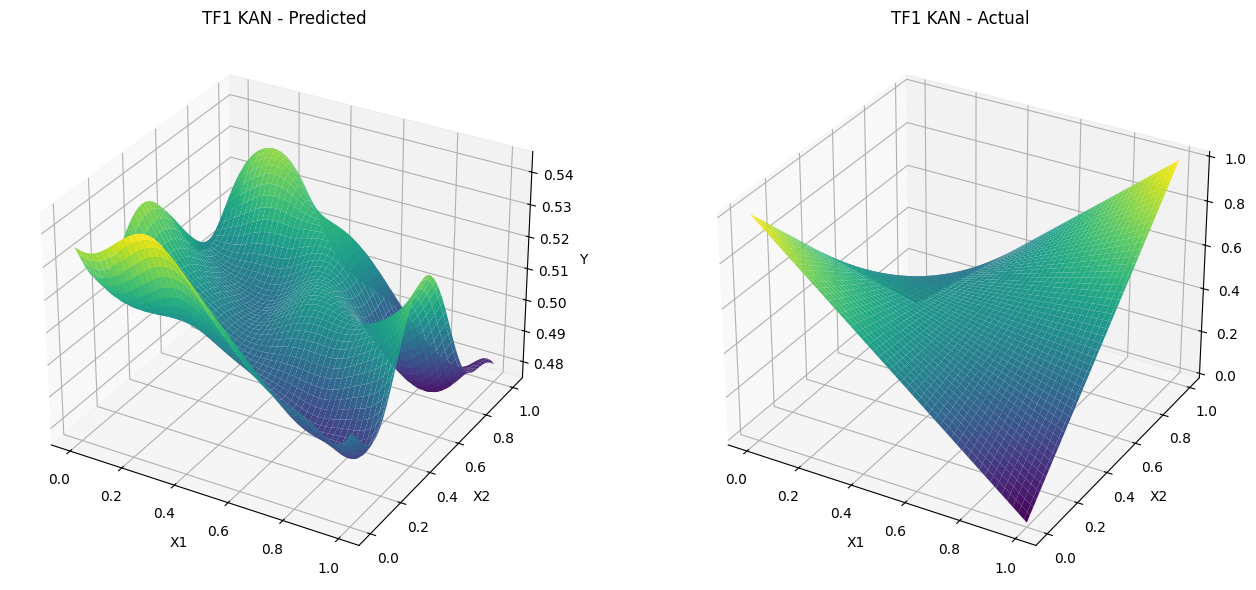

In [27]:
plot_3d_surface("TF1 KAN", tf1_x_test, tf1_y_test, tf1_y_test_pred_kan)

### GP (Gaussian Process Baseline)

In [43]:
def objective_gp(trial, X_train, y_train, X_test, y_test, n_splits=5):
    """
    Objective function for Optuna to find the best GP hyperparameters with K-Fold CV.
    
    Uses K-Fold Cross-Validation on training data to evaluate hyperparameter sets.
    Searches over learning rate, kernel type, and number of inducing points.

    Args:
        trial: Optuna trial object
        X_train, y_train: Training data
        X_test, y_test: Test data for final evaluation
        n_splits: Number of folds for cross-validation (default: 5)

    Returns:
        float: Average validation RMSE across all folds (what Optuna minimizes)
    """
    # Suggest hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)  # Learning rate
    kernel_type = trial.suggest_categorical("kernel", ["rbf", "matern"])  # Kernel type
    num_inducing = trial.suggest_int("num_inducing", 100, 500)  # Inducing points

    # Select kernel based on suggestion
    if kernel_type == "rbf":
        kernel = create_rbf_kernel(X_train.shape[1])
    else:  # matern
        kernel = create_matern_kernel(X_train.shape[1])
    
    # K-Fold Cross-Validation on training data
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_val_rmses = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split into fold train/validation
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]
        
        # Convert to torch tensors
        X_fold_train_t = torch.tensor(X_fold_train, dtype=torch.float64)
        y_fold_train_t = torch.tensor(y_fold_train, dtype=torch.float64)
        X_fold_val_t = torch.tensor(X_fold_val, dtype=torch.float64)
        y_fold_val_t = torch.tensor(y_fold_val, dtype=torch.float64)
        
        # Initialize GP model with suggested hyperparameters
        gp_model, gp_likelihood = gp.init_gp(X_fold_train_t, y_fold_train_t, kernel=kernel, num_inducing=num_inducing)
        
        # Train GP model
        gp_model, gp_likelihood = gp.train_gp(
            gp_model, gp_likelihood, X_fold_train_t, y_fold_train_t,
            num_iters=500, lr=lr
        )
        
        # Evaluate on this fold's validation set
        pred_mean, _ = gp.predict(gp_model, gp_likelihood, X_fold_val_t)
        rmse = em.compute_rmse(pred_mean, y_fold_val_t).item()
        fold_val_rmses.append(rmse)
    
    # Average validation RMSE across all folds (what Optuna minimizes)
    avg_val_rmse = float(np.mean(fold_val_rmses))
    
    # Also evaluate on the actual test set for reference
    X_train_t = torch.tensor(X_train, dtype=torch.float64)
    y_train_t = torch.tensor(y_train, dtype=torch.float64)
    X_test_t = torch.tensor(X_test, dtype=torch.float64)
    y_test_t = torch.tensor(y_test, dtype=torch.float64)
    
    gp_model_final, gp_likelihood_final = gp.init_gp(X_train_t, y_train_t, kernel=kernel, num_inducing=num_inducing)
    gp_model_final, gp_likelihood_final = gp.train_gp(
        gp_model_final, gp_likelihood_final, X_train_t, y_train_t,
        num_iters=500, lr=lr
    )
    
    pred_test, _ = gp.predict(gp_model_final, gp_likelihood_final, X_test_t)
    test_rmse = em.compute_rmse(pred_test, y_test_t).item()
    
    # Store test RMSE as user attribute
    trial.set_user_attr("test_rmse", test_rmse)
    trial.set_user_attr("val_rmse", avg_val_rmse)
    
    return avg_val_rmse


# --- Study setup with K-Fold CV -----------------------------------------------
print("=" * 70)
print("Optimizing GP hyperparameters with 5-Fold Cross-Validation on TF1")
print("=" * 70)

study = optuna.create_study(direction='minimize')

study.optimize(
    lambda trial: objective_gp(trial, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, n_splits=5),
    n_trials=10,
    show_progress_bar=True,
)

# --- Results ---------------------------------------------------------------
print("\n" + "=" * 70)
print("Best trial results:")
print("=" * 70)
print(f"Best CV Validation RMSE: {study.best_value:.6f}")
best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
print(f"Best hyperparameters:")
print(f"  lr:              {study.best_params['lr']:.6f}")
print(f"  kernel:          {study.best_params['kernel']}")
print(f"  num_inducing:    {study.best_params['num_inducing']}")

# Display all trials
trials_df = study.trials_dataframe()
print(f"\nAll {len(trials_df)} trials:")
print(trials_df[['number', 'value', 'params_lr', 'params_kernel', 'params_num_inducing', 'user_attrs_test_rmse']].to_string())

[I 2026-06-05 17:16:27,461] A new study created in memory with name: no-name-a73fe1f8-3fe5-4245-a57b-2901c5350c87


Optimizing GP hyperparameters with 5-Fold Cross-Validation on TF1


  0%|          | 0/10 [00:00<?, ?it/s]

[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=383
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.000214011025410903, loss=ELBO
  Iter 100/500, Loss: 1.354502
  Iter 200/500, Loss: 1.257852
  Iter 300/500, Loss: 1.139341
  Iter 400/500, Loss: 1.023988
  Iter 500/500, Loss: 0.934121
[DEBUG] Training complete.
  Lengthscale: tensor([[0.6068, 0.6072]])
  Outputscale: 0.6533
  Noise: 0.693247
  Mean const: 0.0870
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=383
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.000214011025410903, loss=ELBO
  Iter 100/500, Loss: 1.325995
  Iter 200/500, Loss: 1.240381
  Iter 300/500, Loss: 1.158755
  Iter 400/500, Loss: 1.079784
  Iter 500/500, Loss: 1.011

Best trial: 0. Best value: 0.261977:  10%|█         | 1/10 [02:20<21:01, 140.17s/it]

  Iter 500/500, Loss: 0.913251
[DEBUG] Training complete.
  Lengthscale: tensor([[0.3078, 0.3205]])
  Outputscale: 0.4755
  Noise: 0.693247
  Mean const: 0.0898
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-05 17:18:47,634] Trial 0 finished with value: 0.26197733639920395 and parameters: {'lr': 0.000214011025410903, 'kernel': 'rbf', 'num_inducing': 383}. Best is trial 0 with value: 0.26197733639920395.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=419
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.001546673462482975, loss=ELBO
  Iter 100/500, Loss: 0.906790
  Iter 200/500, Loss: 0.811750
  Iter 300/500, Loss: 0.781435
  Iter 400/500, Loss: 0.768994
  Iter 500/500, Loss: 0.762730
[DEBUG] Training complete.
  Lengthscale: tensor([[0.4975, 0.5103]])
  Outputscale: 0.5765
  Noise: 0.693247
  Mean const: 0.2055
[DEBUG

Best trial: 1. Best value: 0.0373813:  20%|██        | 2/10 [05:56<24:40, 185.03s/it]

  Iter 500/500, Loss: 0.751944
[DEBUG] Training complete.
  Lengthscale: tensor([[0.2024, 0.4066]])
  Outputscale: 0.2287
  Noise: 0.693247
  Mean const: 0.2277
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-05 17:22:24,070] Trial 1 finished with value: 0.03738133629106673 and parameters: {'lr': 0.001546673462482975, 'kernel': 'matern', 'num_inducing': 419}. Best is trial 1 with value: 0.03738133629106673.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=247
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0006291609790068552, loss=ELBO
  Iter 100/500, Loss: 1.179209
  Iter 200/500, Loss: 0.974586
  Iter 300/500, Loss: 0.883783
  Iter 400/500, Loss: 0.842735
  Iter 500/500, Loss: 0.820029
[DEBUG] Training complete.
  Lengthscale: tensor([[0.5545, 0.6226]])
  Outputscale: 0.6111
  Noise: 0.693247
  Mean const: 0.1628
[D

Best trial: 1. Best value: 0.0373813:  30%|███       | 3/10 [07:27<16:33, 141.96s/it]

  Iter 500/500, Loss: 0.787757
[DEBUG] Training complete.
  Lengthscale: tensor([[0.2426, 0.1802]])
  Outputscale: 0.3278
  Noise: 0.693247
  Mean const: 0.1788
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-05 17:23:54,762] Trial 2 finished with value: 0.09375435926721062 and parameters: {'lr': 0.0006291609790068552, 'kernel': 'rbf', 'num_inducing': 247}. Best is trial 1 with value: 0.03738133629106673.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=490
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00045812655197419, loss=ELBO
  Iter 100/500, Loss: 1.209373
  Iter 200/500, Loss: 0.990076
  Iter 300/500, Loss: 0.877880
  Iter 400/500, Loss: 0.832478
  Iter 500/500, Loss: 0.810985
[DEBUG] Training complete.
  Lengthscale: tensor([[0.6172, 0.5719]])
  Outputscale: 0.6364
  Noise: 0.693247
  Mean const: 0.1285
[DEBUG

Best trial: 1. Best value: 0.0373813:  40%|████      | 4/10 [11:47<18:51, 188.52s/it]

  Iter 500/500, Loss: 0.793497
[DEBUG] Training complete.
  Lengthscale: tensor([[0.2877, 0.2301]])
  Outputscale: 0.4146
  Noise: 0.693247
  Mean const: 0.1362
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-05 17:28:14,672] Trial 3 finished with value: 0.10400010016857966 and parameters: {'lr': 0.00045812655197419, 'kernel': 'matern', 'num_inducing': 490}. Best is trial 1 with value: 0.03738133629106673.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=482
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00011350083064752789, loss=ELBO
  Iter 100/500, Loss: 1.385326
  Iter 200/500, Loss: 1.327191
  Iter 300/500, Loss: 1.268610
  Iter 400/500, Loss: 1.209532
  Iter 500/500, Loss: 1.151870
[DEBUG] Training complete.
  Lengthscale: tensor([[0.6451, 0.6503]])
  Outputscale: 0.6684
  Noise: 0.693247
  Mean const: 0.0523
[D

Best trial: 1. Best value: 0.0373813:  50%|█████     | 5/10 [16:04<17:46, 213.29s/it]

  Iter 500/500, Loss: 1.068209
[DEBUG] Training complete.
  Lengthscale: tensor([[0.4530, 0.4579]])
  Outputscale: 0.5558
  Noise: 0.693247
  Mean const: 0.0523
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-05 17:32:31,883] Trial 4 finished with value: 0.37870239308217396 and parameters: {'lr': 0.00011350083064752789, 'kernel': 'matern', 'num_inducing': 482}. Best is trial 1 with value: 0.03738133629106673.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=183
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0008031229508761858, loss=ELBO
  Iter 100/500, Loss: 1.059166
  Iter 200/500, Loss: 0.876123
  Iter 300/500, Loss: 0.814314
  Iter 400/500, Loss: 0.791017
  Iter 500/500, Loss: 0.778833
[DEBUG] Training complete.
  Lengthscale: tensor([[0.5430, 0.5333]])
  Outputscale: 0.6138
  Noise: 0.693247
  Mean const: 0.1620


Best trial: 1. Best value: 0.0373813:  60%|██████    | 6/10 [17:39<11:32, 173.03s/it]

  Iter 500/500, Loss: 0.769483
[DEBUG] Training complete.
  Lengthscale: tensor([[0.2579, 0.2466]])
  Outputscale: 0.3344
  Noise: 0.693247
  Mean const: 0.1832
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-05 17:34:06,754] Trial 5 finished with value: 0.06351446042454761 and parameters: {'lr': 0.0008031229508761858, 'kernel': 'matern', 'num_inducing': 183}. Best is trial 1 with value: 0.03738133629106673.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=199
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.001902994300911821, loss=ELBO
  Iter 100/500, Loss: 0.897767
  Iter 200/500, Loss: 0.789713
  Iter 300/500, Loss: 0.765420
  Iter 400/500, Loss: 0.756824
  Iter 500/500, Loss: 0.752236
[DEBUG] Training complete.
  Lengthscale: tensor([[0.5165, 0.5054]])
  Outputscale: 0.5714
  Noise: 0.693247
  Mean const: 0.1991
[D

Best trial: 1. Best value: 0.0373813:  70%|███████   | 7/10 [18:48<06:57, 139.10s/it]

  Iter 500/500, Loss: 0.749461
[DEBUG] Training complete.
  Lengthscale: tensor([[0.1972, 0.2112]])
  Outputscale: 0.1741
  Noise: 0.693247
  Mean const: 0.2681
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-05 17:35:15,992] Trial 6 finished with value: 0.0375028374028191 and parameters: {'lr': 0.001902994300911821, 'kernel': 'rbf', 'num_inducing': 199}. Best is trial 1 with value: 0.03738133629106673.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0029300171645375846, loss=ELBO
  Iter 100/500, Loss: 0.797332
  Iter 200/500, Loss: 0.762796
  Iter 300/500, Loss: 0.753860
  Iter 400/500, Loss: 0.749619
  Iter 500/500, Loss: 0.747524
[DEBUG] Training complete.
  Lengthscale: tensor([[0.5263, 0.6674]])
  Outputscale: 0.5627
  Noise: 0.693247
  Mean const: 0.1955
[DEBUG

Best trial: 7. Best value: 0.0224218:  80%|████████  | 8/10 [22:06<05:15, 157.77s/it]

  Iter 500/500, Loss: 0.743572
[DEBUG] Training complete.
  Lengthscale: tensor([[0.3663, 0.5646]])
  Outputscale: 0.1696
  Noise: 0.693247
  Mean const: 0.2570
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-05 17:38:33,753] Trial 7 finished with value: 0.022421834521192587 and parameters: {'lr': 0.0029300171645375846, 'kernel': 'matern', 'num_inducing': 388}. Best is trial 7 with value: 0.022421834521192587.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=122
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.000175818154130619, loss=ELBO
  Iter 100/500, Loss: 1.333077
  Iter 200/500, Loss: 1.228311
  Iter 300/500, Loss: 1.136207
  Iter 400/500, Loss: 1.057296
  Iter 500/500, Loss: 0.990901
[DEBUG] Training complete.
  Lengthscale: tensor([[0.6333, 0.6339]])
  Outputscale: 0.6596
  Noise: 0.693247
  Mean const: 0.0744


Best trial: 7. Best value: 0.0224218:  90%|█████████ | 9/10 [22:59<02:05, 125.18s/it]

  Iter 500/500, Loss: 0.943842
[DEBUG] Training complete.
  Lengthscale: tensor([[0.3699, 0.3726]])
  Outputscale: 0.5104
  Noise: 0.693247
  Mean const: 0.0762
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-05 17:39:27,263] Trial 8 finished with value: 0.2926146825495163 and parameters: {'lr': 0.000175818154130619, 'kernel': 'matern', 'num_inducing': 122}. Best is trial 7 with value: 0.022421834521192587.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=273
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00048376928763560196, loss=ELBO
  Iter 100/500, Loss: 1.228187
  Iter 200/500, Loss: 1.037643
  Iter 300/500, Loss: 0.927759
  Iter 400/500, Loss: 0.867654
  Iter 500/500, Loss: 0.830459
[DEBUG] Training complete.
  Lengthscale: tensor([[0.5829, 0.5798]])
  Outputscale: 0.6237
  Noise: 0.693247
  Mean const: 0.1404
[

Best trial: 7. Best value: 0.0224218: 100%|██████████| 10/10 [24:32<00:00, 147.29s/it]

  Iter 500/500, Loss: 0.805126
[DEBUG] Training complete.
  Lengthscale: tensor([[0.2431, 0.1891]])
  Outputscale: 0.3644
  Noise: 0.693247
  Mean const: 0.1504
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-05 17:41:00,338] Trial 9 finished with value: 0.1394100938537318 and parameters: {'lr': 0.00048376928763560196, 'kernel': 'rbf', 'num_inducing': 273}. Best is trial 7 with value: 0.022421834521192587.

Best trial results:
Best CV Validation RMSE: 0.022422
Best Test RMSE:          0.028800
Best hyperparameters:
  lr:              0.002930
  kernel:          matern
  num_inducing:    388

All 10 trials:
   number     value  params_lr params_kernel  params_num_inducing  user_attrs_test_rmse
0       0  0.261977   0.000214           rbf                  383              0.265265
1       1  0.037381   0.001547        matern                  419              0.038695
2       2  0.093754   0.000629           rbf   

In [46]:
trials_df = trials_df.rename(columns={
    "user_attrs_test_rmse": "test_rmse",
    "user_attrs_val_rmse": "val_rmse",
})
trials_df['duration'] = trials_df['duration'].dt.total_seconds()
trials_df.to_csv("data/tf1_gp_optuna_search.csv")

Training Gaussian Process baseline on TF1
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=388

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.785840
  Iter 200/500, Loss: 0.756883
  Iter 300/500, Loss: 0.749778
  Iter 400/500, Loss: 0.747010
  Iter 500/500, Loss: 0.745450
[DEBUG] Training complete.
  Lengthscale: tensor([[0.5882, 0.6336]])
  Outputscale: 0.5736
  Noise: 0.693247
  Mean const: 0.1785
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             7.599134e-03         7.850771e-03        
RMSE            1.342649e-02         1.400785e-02        
[DEBUG] SparseGPModel and li

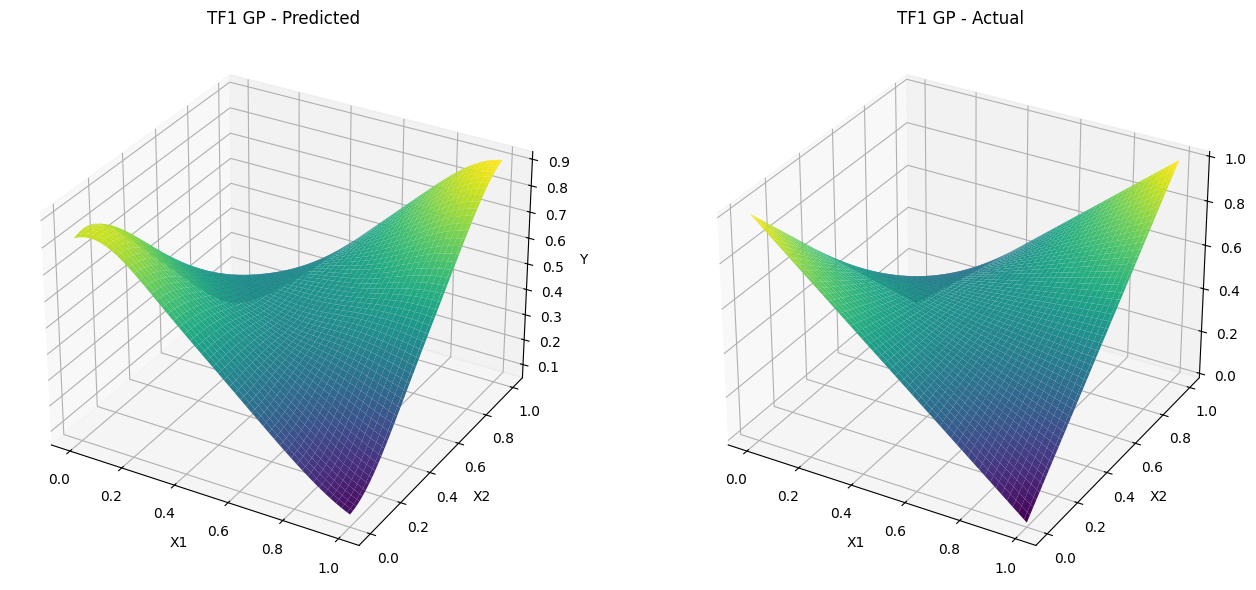

In [47]:
# Wrapper for GP model to add predict method for em.evaluate compatibility
class GPModel:
    """Wrapper for Gaussian Process model for compatibility with em.evaluate()."""
    
    def __init__(self, model, likelihood):
        self.model = model
        self.likelihood = likelihood
    
    def predict(self, X):
        """Make predictions with the GP model."""
        X_tensor = torch.tensor(X, dtype=torch.float64)
        pred_mean, pred_std = gp.predict(self.model, self.likelihood, X_tensor)
        return pred_mean.cpu().numpy()


# TF1 GP Model Training
print("=" * 70)
print("Training Gaussian Process baseline on TF1")
print("=" * 70)

# Convert to torch tensors with float64
X_train_gp = torch.tensor(tf1_x_train, dtype=torch.float64)
y_train_gp = torch.tensor(tf1_y_train, dtype=torch.float64)
X_test_gp = torch.tensor(tf1_x_test, dtype=torch.float64)
y_test_gp = torch.tensor(tf1_y_test, dtype=torch.float64)

# Initialize GP model and likelihood
tf1_gp_model, tf1_gp_likelihood = gp.init_gp(
    X_train_gp,
    y_train_gp,
    kernel=create_matern_kernel(tf1_x_train.shape[1]),
    num_inducing=388
)

# Train GP model
print("\nTraining GP...")
tf1_gp_model, tf1_gp_likelihood = gp.train_gp(
    tf1_gp_model,
    tf1_gp_likelihood,
    X_train_gp,
    y_train_gp,
    num_iters=500,
    lr=0.002930
)

# Evaluate GP model
print("\nEvaluating GP...")
tf1_gp_results = em.evaluate(
    GPModel(tf1_gp_model, tf1_gp_likelihood),
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

print_results(tf1_gp_results)

# Make predictions for visualization
tf1_gp_y_test_pred, _ = gp.predict(tf1_gp_model, tf1_gp_likelihood, X_test_gp)
tf1_gp_y_test_pred = tf1_gp_y_test_pred.cpu().numpy()

plot_3d_surface("TF1 GP", tf1_x_test, tf1_y_test, tf1_gp_y_test_pred)

### SGKAN

### SGKAN (Surrogate-Guided KAN) - Hyperparameter Optimization

In [68]:
def objective_sgkan(trial, X_train, y_train, X_test, y_test, n_splits=5):
    """
    Objective function for Optuna to find the best SGKAN layer configuration with K-Fold CV.
    
    Uses K-Fold Cross-Validation on training data to evaluate hyperparameter sets.
    Searches over SGKAN layer width, M (pair samples), G (grid), and T (interior points).
    GP hyperparameters are kept fixed.

    Args:
        trial: Optuna trial object
        X_train, y_train: Training data
        X_test, y_test: Test data for final evaluation
        n_splits: Number of folds for cross-validation (default: 5)

    Returns:
        float: Average validation RMSE across all folds (what Optuna minimizes)
    """
    # Suggest SGKAN hyperparameters
    width = trial.suggest_int("width", 32, 200)  # Layer width
    M = trial.suggest_int("M", 500, 1000)  # Number of candidate pairs
    G = trial.suggest_int("G", 25, 100)  # Grid size for edge functions
    T = trial.suggest_int("T", 5, 50)  # Interior points between pairs
    
    # Fixed GP hyperparameters
    num_iters=500
    lr=0.002930
    num_inducing = 388
    
    # Layer configuration with suggested hyperparameters
    layer_config = [{"width": width, "M": M, "G": G, "T": T}]
    
    # K-Fold Cross-Validation on training data
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_val_rmses = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split into fold train/validation (ensure numpy arrays)
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]
        
        # Build and train SGKAN with suggested hyperparameters
        sgkan_layers, sgkan_W_out = fit_sgkan(
            X_fold_train, y_fold_train, layer_config,
            activation=torch.tanh,
            kernel=create_matern_kernel(X_fold_train.shape[1]),
            lr=lr, num_inducing=num_inducing, num_iters=num_iters
        )
        
        # Evaluate on this fold's validation set
        sgkan_pred_val = sgkan.predict_sgkan(sgkan_layers, sgkan_W_out, X_fold_val, activation=torch.tanh)
        rmse = em.compute_rmse(
            torch.tensor(sgkan_pred_val.flatten(), dtype=torch.float64),
            torch.tensor(y_fold_val.flatten(), dtype=torch.float64)
        ).item()
        fold_val_rmses.append(rmse)
    
    # Average validation RMSE across all folds (what Optuna minimizes)
    avg_val_rmse = float(np.mean(fold_val_rmses))
    
    sgkan_layers_final, sgkan_W_out_final = fit_sgkan(
        X_train, y_train, layer_config,
        activation=torch.tanh,
        kernel=create_matern_kernel(X_train.shape[1]),
        lr=lr, num_inducing=num_inducing, num_iters=num_iters
    )
    
    sgkan_pred_test = sgkan.predict_sgkan(sgkan_layers_final, sgkan_W_out_final, X_test, activation=torch.tanh)
    test_rmse = em.compute_rmse(
        torch.tensor(sgkan_pred_test.flatten(), dtype=torch.float64),
        torch.tensor(y_test.flatten(), dtype=torch.float64)
    ).item()
    
    # Store test RMSE as user attribute
    trial.set_user_attr("test_rmse", test_rmse)
    trial.set_user_attr("val_rmse", avg_val_rmse)
    
    return avg_val_rmse


# --- Study setup with K-Fold CV -----------------------------------------------
print("=" * 70)
print("Optimizing SGKAN hyperparameters with 5-Fold Cross-Validation on TF1")
print("=" * 70)

study = optuna.create_study(direction='minimize')

study.optimize(
    lambda trial: objective_sgkan(trial, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, n_splits=5),
    n_trials=10,
    show_progress_bar=True,
)

# --- Results ---------------------------------------------------------------
print("\n" + "=" * 70)
print("Best trial results:")
print("=" * 70)
print(f"Best CV Validation RMSE: {study.best_value:.6f}")
best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
print(f"Best hyperparameters:")
print(f"  width:  {study.best_params['width']}")
print(f"  M:      {study.best_params['M']}")
print(f"  G:      {study.best_params['G']}")
print(f"  T:      {study.best_params['T']}")

# Display all trials
trials_df = study.trials_dataframe()
print(f"\nAll {len(trials_df)} trials:")
print(trials_df[['number', 'value', 'params_width', 'params_M', 'params_G', 'params_T', 'user_attrs_test_rmse']].to_string())

[I 2026-06-05 18:16:20,394] A new study created in memory with name: no-name-e120f44d-f432-4701-8112-5daf5e2633d9


Optimizing SGKAN hyperparameters with 5-Fold Cross-Validation on TF1


  0%|          | 0/10 [00:00<?, ?it/s]


─── Layer 1 | input: torch.Size([4000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.805633
  Iter 200/500, Loss: 0.765668
  Iter 300/500, Loss: 0.756342
  Iter 400/500, Loss: 0.752917
  Iter 500/500, Loss: 0.750644
[DEBUG] Training complete.
  Lengthscale: tensor([[0.5357, 0.5525]])
  Outputscale: 0.5500
  Noise: 0.693247
  Mean const: 0.2178
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0085, max=0.8062, mean=0.3113
[DEBUG] Probs:  min=0.000048,  max=0.004559,  sum=1.000000
[DEBUG] Selected 138 pairs from 568 candidates
[DEBUG] Unique pairs selected: 123 / 138
[DEBUG] x_segments shape:     torch.Size([138, 65, 2])
[DEBUG] edge_functions shape: torch.Size([138, 65])
[DEBUG] Value range: [0.1122, 0.8829]
[DEBUG] H shape: torch.Size([4000, 138])
[DEBUG] H val

/var/folders/5g/94j7hdwx0k5fpcdmgs_76q4c0000gn/T/ipykernel_1851/114148867.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(sgkan_pred_val.flatten(), dtype=torch.float64),


  Iter 100/500, Loss: 0.788720
  Iter 200/500, Loss: 0.759358
  Iter 300/500, Loss: 0.753306
  Iter 400/500, Loss: 0.750009
  Iter 500/500, Loss: 0.748467
[DEBUG] Training complete.
  Lengthscale: tensor([[0.5344, 0.6362]])
  Outputscale: 0.5700
  Noise: 0.693247
  Mean const: 0.1889
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0046, max=0.8932, mean=0.3642
[DEBUG] Probs:  min=0.000022,  max=0.004318,  sum=1.000000
[DEBUG] Selected 138 pairs from 568 candidates
[DEBUG] Unique pairs selected: 124 / 138
[DEBUG] x_segments shape:     torch.Size([138, 65, 2])
[DEBUG] edge_functions shape: torch.Size([138, 65])
[DEBUG] Value range: [0.0913, 0.8669]
[DEBUG] H shape: torch.Size([4000, 138])
[DEBUG] H value range: [0.0913, 0.8669]
[DEBUG] H rank (approx): 124
[DEBUG] W_out shape: torch.Size([139, 1])

✓ Training completed in 31.6460 seconds
[DEBUG] H shape: torch.Size([1000, 138])
[DEBUG] H value range: [0.0975, 0.8669]
[DEBUG] H rank (approx): 124

─── Layer 1

/var/folders/5g/94j7hdwx0k5fpcdmgs_76q4c0000gn/T/ipykernel_1851/114148867.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(sgkan_pred_test.flatten(), dtype=torch.float64),
Best trial: 0. Best value: 0.00473928:  10%|█         | 1/10 [03:12<28:55, 192.84s/it]

[DEBUG] W_out shape: torch.Size([139, 1])

✓ Training completed in 36.2051 seconds
[DEBUG] H shape: torch.Size([10000, 138])
[DEBUG] H value range: [0.1276, 0.9029]
[DEBUG] H rank (approx): 118
[I 2026-06-05 18:19:33,232] Trial 0 finished with value: 0.004739277544314469 and parameters: {'width': 138, 'M': 568, 'G': 65, 'T': 35}. Best is trial 0 with value: 0.004739277544314469.

─── Layer 1 | input: torch.Size([4000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.785442
  Iter 200/500, Loss: 0.751759
  Iter 300/500, Loss: 0.747149
  Iter 400/500, Loss: 0.745412
  Iter 500/500, Loss: 0.744616
[DEBUG] Training complete.
  Lengthscale: tensor([[0.6926, 0.6283]])
  Outputscale: 0.5863
  Noise: 0.693247
  Mean const: 0.1340
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: 

Best trial: 0. Best value: 0.00473928:  20%|██        | 2/10 [06:35<26:27, 198.38s/it]

[DEBUG] x_segments shape:     torch.Size([117, 75, 2])
[DEBUG] edge_functions shape: torch.Size([117, 75])
[DEBUG] Value range: [0.0982, 0.8970]
[DEBUG] H shape: torch.Size([5000, 117])
[DEBUG] H value range: [0.0982, 0.8970]
[DEBUG] H rank (approx): 108
[DEBUG] W_out shape: torch.Size([118, 1])

✓ Training completed in 38.0807 seconds
[DEBUG] H shape: torch.Size([10000, 117])
[DEBUG] H value range: [0.0982, 0.8970]
[DEBUG] H rank (approx): 108
[I 2026-06-05 18:22:55,497] Trial 1 finished with value: 0.005377061646176981 and parameters: {'width': 117, 'M': 842, 'G': 75, 'T': 12}. Best is trial 0 with value: 0.004739277544314469.

─── Layer 1 | input: torch.Size([4000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.822969
  Iter 200/500, Loss: 0.771876
  Iter 300/500, Loss: 0.759564
  Iter 40

Best trial: 2. Best value: 0.00340115:  30%|███       | 3/10 [09:57<23:22, 200.35s/it]

[DEBUG] x_segments shape:     torch.Size([197, 81, 2])
[DEBUG] edge_functions shape: torch.Size([197, 81])
[DEBUG] Value range: [0.0658, 0.8971]
[DEBUG] H shape: torch.Size([5000, 197])
[DEBUG] H value range: [0.0658, 0.8971]
[DEBUG] H rank (approx): 182
[DEBUG] W_out shape: torch.Size([198, 1])

✓ Training completed in 39.1010 seconds
[DEBUG] H shape: torch.Size([10000, 197])
[DEBUG] H value range: [0.0658, 0.8971]
[DEBUG] H rank (approx): 182
[I 2026-06-05 18:26:18,187] Trial 2 finished with value: 0.0034011463210453555 and parameters: {'width': 197, 'M': 954, 'G': 81, 'T': 20}. Best is trial 2 with value: 0.0034011463210453555.

─── Layer 1 | input: torch.Size([4000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.792965
  Iter 200/500, Loss: 0.762015
  Iter 300/500, Loss: 0.754718
  Iter 

Best trial: 2. Best value: 0.00340115:  40%|████      | 4/10 [13:10<19:42, 197.16s/it]

[DEBUG] Scores: min=0.0024, max=0.8146, mean=0.3165
[DEBUG] Probs:  min=0.000008,  max=0.002645,  sum=1.000000
[DEBUG] Selected 59 pairs from 973 candidates
[DEBUG] Unique pairs selected: 55 / 59
[DEBUG] x_segments shape:     torch.Size([59, 57, 2])
[DEBUG] edge_functions shape: torch.Size([59, 57])
[DEBUG] Value range: [0.1065, 0.8783]
[DEBUG] H shape: torch.Size([5000, 59])
[DEBUG] H value range: [0.1065, 0.8783]
[DEBUG] H rank (approx): 55
[DEBUG] W_out shape: torch.Size([60, 1])

✓ Training completed in 36.6331 seconds
[DEBUG] H shape: torch.Size([10000, 59])
[DEBUG] H value range: [0.1065, 0.8783]
[DEBUG] H rank (approx): 55
[I 2026-06-05 18:29:30,445] Trial 3 finished with value: 0.010231207995042355 and parameters: {'width': 59, 'M': 973, 'G': 57, 'T': 33}. Best is trial 2 with value: 0.0034011463210453555.

─── Layer 1 | input: torch.Size([4000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood 

Best trial: 2. Best value: 0.00340115:  50%|█████     | 5/10 [16:28<16:27, 197.49s/it]

[I 2026-06-05 18:32:48,538] Trial 4 finished with value: 0.005513349446635564 and parameters: {'width': 125, 'M': 626, 'G': 74, 'T': 41}. Best is trial 2 with value: 0.0034011463210453555.

─── Layer 1 | input: torch.Size([4000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.811624
  Iter 200/500, Loss: 0.767601
  Iter 300/500, Loss: 0.755759
  Iter 400/500, Loss: 0.751318
  Iter 500/500, Loss: 0.748622
[DEBUG] Training complete.
  Lengthscale: tensor([[0.4840, 0.6612]])
  Outputscale: 0.5431
  Noise: 0.693247
  Mean const: 0.1962
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0040, max=0.6411, mean=0.2388
[DEBUG] Probs:  min=0.000020,  max=0.003103,  sum=1.000000
[DEBUG] Selected 61 pairs from 865 candidates
[DEBUG] Unique pairs selected: 56 / 61
[DEBUG] x_seg

Best trial: 2. Best value: 0.00340115:  60%|██████    | 6/10 [19:39<13:01, 195.47s/it]

[DEBUG] Scores: min=0.0111, max=0.7268, mean=0.2959
[DEBUG] Probs:  min=0.000044,  max=0.002840,  sum=1.000000
[DEBUG] Selected 61 pairs from 865 candidates
[DEBUG] Unique pairs selected: 58 / 61
[DEBUG] x_segments shape:     torch.Size([61, 56, 2])
[DEBUG] edge_functions shape: torch.Size([61, 56])
[DEBUG] Value range: [0.1033, 0.8610]
[DEBUG] H shape: torch.Size([5000, 61])
[DEBUG] H value range: [0.1033, 0.8610]
[DEBUG] H rank (approx): 58
[DEBUG] W_out shape: torch.Size([62, 1])

✓ Training completed in 37.2361 seconds
[DEBUG] H shape: torch.Size([10000, 61])
[DEBUG] H value range: [0.1033, 0.8610]
[DEBUG] H rank (approx): 58
[I 2026-06-05 18:36:00,066] Trial 5 finished with value: 0.011485243927425814 and parameters: {'width': 61, 'M': 865, 'G': 56, 'T': 49}. Best is trial 2 with value: 0.0034011463210453555.

─── Layer 1 | input: torch.Size([4000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood 

Best trial: 2. Best value: 0.00340115:  70%|███████   | 7/10 [22:53<09:44, 194.87s/it]

[DEBUG] x_segments shape:     torch.Size([151, 79, 2])
[DEBUG] edge_functions shape: torch.Size([151, 79])
[DEBUG] Value range: [0.0894, 0.9071]
[DEBUG] H shape: torch.Size([5000, 151])
[DEBUG] H value range: [0.0894, 0.9071]
[DEBUG] H rank (approx): 138
[DEBUG] W_out shape: torch.Size([152, 1])

✓ Training completed in 38.3905 seconds
[DEBUG] H shape: torch.Size([10000, 151])
[DEBUG] H value range: [0.0894, 0.9071]
[DEBUG] H rank (approx): 138
[I 2026-06-05 18:39:13,710] Trial 6 finished with value: 0.0041567292996040036 and parameters: {'width': 151, 'M': 713, 'G': 79, 'T': 16}. Best is trial 2 with value: 0.0034011463210453555.

─── Layer 1 | input: torch.Size([4000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.811217
  Iter 200/500, Loss: 0.771046
  Iter 300/500, Loss: 0.758788
  Iter 

Best trial: 2. Best value: 0.00340115:  80%|████████  | 8/10 [26:09<06:30, 195.41s/it]

[DEBUG] H rank (approx): 139
[I 2026-06-05 18:42:30,273] Trial 7 finished with value: 0.004468917856049368 and parameters: {'width': 154, 'M': 872, 'G': 36, 'T': 25}. Best is trial 2 with value: 0.0034011463210453555.

─── Layer 1 | input: torch.Size([4000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.787489
  Iter 200/500, Loss: 0.755905
  Iter 300/500, Loss: 0.749186
  Iter 400/500, Loss: 0.746274
  Iter 500/500, Loss: 0.744883
[DEBUG] Training complete.
  Lengthscale: tensor([[0.6963, 0.7227]])
  Outputscale: 0.5812
  Noise: 0.693247
  Mean const: 0.1414
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0413, max=2.8656, mean=1.1939
[DEBUG] Probs:  min=0.000054,  max=0.003750,  sum=1.000000
[DEBUG] Selected 180 pairs from 640 candidates
[DEBUG] Unique pairs s

Best trial: 2. Best value: 0.00340115:  90%|█████████ | 9/10 [29:30<03:16, 196.91s/it]

[DEBUG] x_segments shape:     torch.Size([180, 28, 2])
[DEBUG] edge_functions shape: torch.Size([180, 28])
[DEBUG] Value range: [0.1151, 0.8585]
[DEBUG] H shape: torch.Size([5000, 180])
[DEBUG] H value range: [0.1151, 0.8585]
[DEBUG] H rank (approx): 158
[DEBUG] W_out shape: torch.Size([181, 1])

✓ Training completed in 36.5664 seconds
[DEBUG] H shape: torch.Size([10000, 180])
[DEBUG] H value range: [0.1151, 0.8585]
[DEBUG] H rank (approx): 158
[I 2026-06-05 18:45:50,492] Trial 8 finished with value: 0.0036756631050450734 and parameters: {'width': 180, 'M': 640, 'G': 28, 'T': 10}. Best is trial 2 with value: 0.0034011463210453555.

─── Layer 1 | input: torch.Size([4000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.798011
  Iter 200/500, Loss: 0.761774
  Iter 300/500, Loss: 0.753697
  Iter 

Best trial: 2. Best value: 0.00340115: 100%|██████████| 10/10 [32:40<00:00, 196.03s/it]

[DEBUG] x_segments shape:     torch.Size([122, 79, 2])
[DEBUG] edge_functions shape: torch.Size([122, 79])
[DEBUG] Value range: [0.1039, 0.8693]
[DEBUG] H shape: torch.Size([5000, 122])
[DEBUG] H value range: [0.1039, 0.8693]
[DEBUG] H rank (approx): 111
[DEBUG] W_out shape: torch.Size([123, 1])

✓ Training completed in 36.7721 seconds
[DEBUG] H shape: torch.Size([10000, 122])
[DEBUG] H value range: [0.1039, 0.8693]
[DEBUG] H rank (approx): 111
[I 2026-06-05 18:49:00,648] Trial 9 finished with value: 0.005172419318587677 and parameters: {'width': 122, 'M': 873, 'G': 79, 'T': 16}. Best is trial 2 with value: 0.0034011463210453555.

Best trial results:
Best CV Validation RMSE: 0.003401
Best Test RMSE:          0.004079
Best hyperparameters:
  width:  197
  M:      954
  G:      81
  T:      20

All 10 trials:
   number     value  params_width  params_M  params_G  params_T  user_attrs_test_rmse
0       0  0.004739           138       568        65        35              0.006497
1       1

In [69]:
trials_df = trials_df.rename(columns={
    "user_attrs_test_rmse": "test_rmse",
    "user_attrs_val_rmse": "val_rmse",
})
trials_df['duration'] = trials_df['duration'].dt.total_seconds()
trials_df.to_csv("data/tf1_sgkan_optuna_search.csv")

In [70]:
# TF1 SGKAN layer configuration
# Single layer with width=5 to match KAN architecture
tf1_sgkan_layer_configs = [
    {"width": 197, "M": 954, "G": 81, "T": 20}
]

# Kernel options (available for use with gp.init_gp):
# - Default (RBF with ARD): passed implicitly
# - Custom Matern: kernel = create_matern_kernel(tf1_x_train.shape[1])
# - Custom RBF: kernel = create_rbf_kernel(tf1_x_train.shape[1])

# Train TF1 SGKAN (currently uses default RBF kernel)
# To use custom kernel, modify sgkan.build_sgkan to accept kernel parameter
tf1_sgkan_layers, tf1_sgkan_W_out = fit_sgkan(
    tf1_x_train, tf1_y_train, 
    tf1_sgkan_layer_configs,
    num_inducing=388,
    num_iters=500,
    lr=0.002930,
    activation=torch.tanh,
    kernel=create_matern_kernel(tf1_x_train.shape[1])
)


─── Layer 1 | input: torch.Size([5000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.793625
  Iter 200/500, Loss: 0.764131
  Iter 300/500, Loss: 0.754407
  Iter 400/500, Loss: 0.750839
  Iter 500/500, Loss: 0.748460
[DEBUG] Training complete.
  Lengthscale: tensor([[0.5158, 0.5924]])
  Outputscale: 0.5577
  Noise: 0.693247
  Mean const: 0.1899
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0106, max=1.6239, mean=0.6712
[DEBUG] Probs:  min=0.000017,  max=0.002536,  sum=1.000000
[DEBUG] Selected 197 pairs from 954 candidates
[DEBUG] Unique pairs selected: 183 / 197
[DEBUG] x_segments shape:     torch.Size([197, 81, 2])
[DEBUG] edge_functions shape: torch.Size([197, 81])
[DEBUG] Value range: [0.1124, 0.8476]
[DEBUG] H shape: torch.Size([5000, 197])
[DEBUG] H val

In [71]:
# Wrapper for SGKAN model to add predict method for em.evaluate compatibility
class SGKANModel:
    def __init__(self, layers, W_out, activation=torch.tanh):
        self.layers = layers
        self.W_out = W_out
        self.activation = activation
    
    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float64)
        return sgkan.predict_sgkan(self.layers, self.W_out, X_tensor, activation=self.activation).detach().numpy()

tf1_sgkan_results = em.evaluate(
    SGKANModel(tf1_sgkan_layers, tf1_sgkan_W_out, activation=torch.tanh),
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

[DEBUG] H shape: torch.Size([5000, 197])
[DEBUG] H value range: [0.1124, 0.8476]
[DEBUG] H rank (approx): 183
[DEBUG] H shape: torch.Size([10000, 197])
[DEBUG] H value range: [0.1124, 0.8476]
[DEBUG] H rank (approx): 183


In [72]:
print_results(tf1_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.202595e-03         2.395626e-03        
RMSE            2.941052e-03         3.357585e-03        


In [73]:
tf1_sgkan_y_test_pred = predict_sgkan(tf1_sgkan_layers, tf1_sgkan_W_out, tf1_x_test, activation=torch.tanh)

[DEBUG] H shape: torch.Size([10000, 197])
[DEBUG] H value range: [0.1124, 0.8476]
[DEBUG] H rank (approx): 183
✓ Prediction completed in 0.0695 seconds


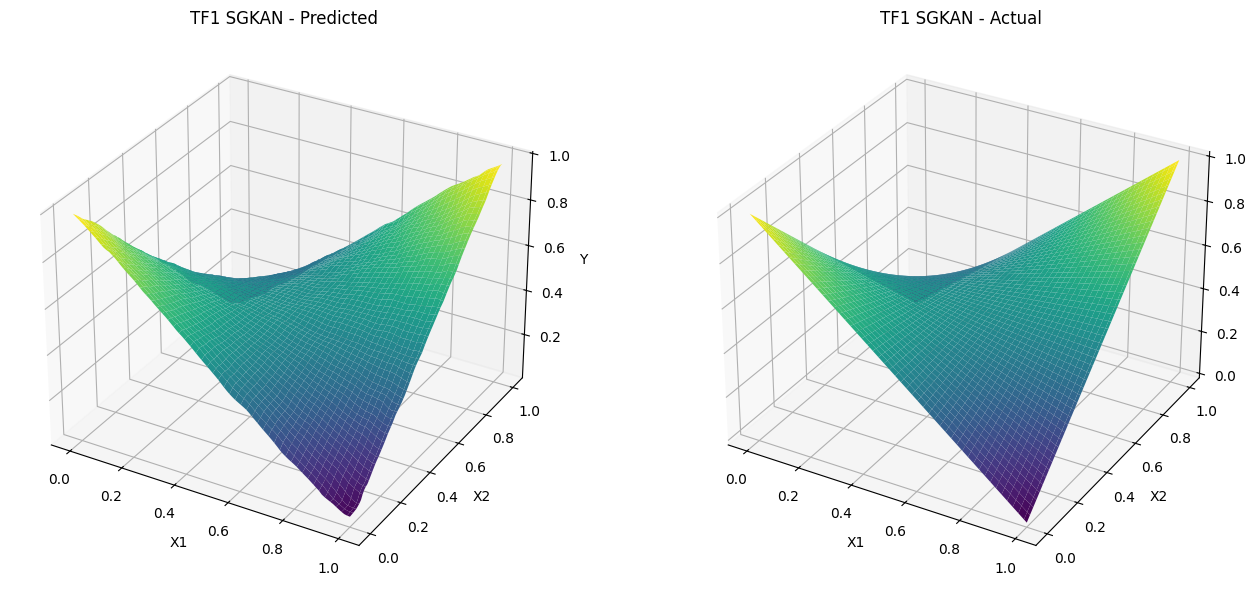

In [74]:
plot_3d_surface("TF1 SGKAN", tf1_x_test, tf1_y_test, tf1_sgkan_y_test_pred)

## TF5 Results

### HKAN

In [ ]:
# Load tf5 dataset
tf5 = load_dataset("TF5")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = tf5["train_input"], tf5["test_input"], tf5["train_label"], tf5["test_label"]

In [ ]:
print("TF5 X_train shape:", tf5_x_train.shape)
print("TF5 X_test shape:", tf5_x_test.shape)
print("TF5 y_train range:", tf5_y_train.min(), tf5_y_train.max())
print("TF5 y_train mean:", tf5_y_train.mean())

In [ ]:
# TF5 model params
tf5_model_params = [
    {
        "layer": 0,
        "n_vars_out": 912,
        "basis_fn": Tanh(s=50),
        "n_basis": 23,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.01),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.1),
    }
]
tf5_model = build_hkan_from_params(tf5_model_params)
tf5_model

In [ ]:
# Fit HKAN
fit_hkan(tf5_model, tf5_x_train, tf5_y_train)
tf5_results = em.evaluate(
    tf5_model,
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

In [ ]:
print_results(tf5_results)

In [ ]:
tf5_y_test_pred = predict_hkan(tf5_model, tf5_x_test)

In [ ]:
plot_3d_surface("TF5", tf5_x_test, tf5_y_test, tf5_y_test_pred)

### KAN

In [ ]:
# Create TF5 KAN model with architecture [2, 5, 1]
tf5_kan_model = build_kan(width=[2, 5, 1], grid=3, k=3, seed=42)
print("TF5 KAN model created with architecture [2, 5, 1]")

In [ ]:
# Train TF5 KAN model
fit_kan(tf5_kan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, steps=50, opt="LBFGS", lamb=0.01)

tf5_kan_results = em.evaluate(
    KANModel(tf5_kan_model),
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

In [ ]:
print_results(tf5_kan_results)

In [ ]:
tf5_y_test_pred_kan = predict_kan(tf5_kan_model, tf5_x_test)

In [ ]:
plot_3d_surface("TF5 KAN", tf5_x_test, tf5_y_test, tf5_y_test_pred_kan)

### SGKAN

In [ ]:
# TF5 SGKAN layer configuration
tf5_sgkan_layer_configs = [
    {"width": 128, "M": 5000, "G": 50, "T": 10}
]

# Kernel options (available for use with gp.init_gp):
# - Default (RBF with ARD): passed implicitly
# - Custom Matern: kernel = create_matern_kernel(tf5_x_train.shape[1])
# - Custom RBF: kernel = create_rbf_kernel(tf5_x_train.shape[1])
# - Product: kernel = create_rbf_matern_kernel(tf5_x_train.shape[1])

# Train TF5 SGKAN (currently uses default RBF kernel)
# To use custom kernel, modify sgkan.build_sgkan to accept kernel parameter
tf5_sgkan_layers, tf5_sgkan_W_out = fit_sgkan(
    tf5_x_train, tf5_y_train, 
    tf5_sgkan_layer_configs, 
    activation=torch.tanh,
    kernel=create_matern_kernel(tf5_x_train.shape[1])
)

In [ ]:
tf5_sgkan_results = em.evaluate(
    SGKANModel(tf5_sgkan_layers, tf5_sgkan_W_out, activation=torch.tanh),
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

In [ ]:
print_results(tf5_sgkan_results)

In [ ]:
tf5_sgkan_y_test_pred = predict_sgkan(tf5_sgkan_layers, tf5_sgkan_W_out, tf5_x_test, activation=torch.tanh)

In [ ]:
plot_3d_surface("TF5 SGKAN", tf5_x_test, tf5_y_test, tf5_sgkan_y_test_pred)